## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import time
import pickle
from sklearn.metrics import r2_score
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")

## Training parameters

In [2]:
num_epochs = 100
save_every = 10
learning_rate = 0.0001
batch_size = 64
model_num = 2
num_samples = 6560   # Keep simulated data, upsample experimental data
duration = 15.47
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Single_Layer'
fname = os.path.join(data_dir, '1_layer_SimData_1547.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,3:]    
Sim_Label = SimData[:,0:3]

SimTime = np.arange(15.47/6560,15.47+15.47/6560,15.47/6560)[:-1] # Total time is 15.47 ns

SimTrain_Data = Sim_Data
SimTrain_Label = Sim_Label

In [5]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(16500, 6560)
(16500, 3)


### Experimental data

In [6]:
fname = os.path.join(data_dir, '1_layer_TEST_ExpData.xlsx')
ExpTest = pd.read_excel(fname)

# Time
ExpTest_Time_1 = np.tile(ExpTest.iloc[2, 4:514].to_numpy(), (25,1))
ExpTest_Time_2 = np.tile(ExpTest.iloc[33, 4:514].to_numpy(), (25,1))
ExpTest_Time_3 = np.tile(ExpTest.iloc[65, 4:514].to_numpy(), (25,1))
ExpTest_Time_4 = np.tile(ExpTest.iloc[97, 4:514].to_numpy(), (25,1))
ExpTest_Time_5 = np.tile(ExpTest.iloc[129, 4:514].to_numpy(), (25,1))
ExpTest_Time_6 = np.tile(ExpTest.iloc[162, 4:514].to_numpy(), (25,1))
ExpTest_Time = np.concatenate((ExpTest_Time_1, ExpTest_Time_2, ExpTest_Time_3, ExpTest_Time_4,
                               ExpTest_Time_5, ExpTest_Time_6), axis=0)

# Label
ExpTest_Label_1 = ExpTest.iloc[3:28, 0:3].to_numpy()
ExpTest_Label_2 = ExpTest.iloc[34:59, 0:3].to_numpy()
ExpTest_Label_3 = ExpTest.iloc[66:91, 0:3].to_numpy()
ExpTest_Label_4 = ExpTest.iloc[98:123, 0:3].to_numpy()
ExpTest_Label_5 = ExpTest.iloc[130:155, 0:3].to_numpy()
ExpTest_Label_6 = ExpTest.iloc[163:188, 0:3].to_numpy()
ExpTest_Label = np.concatenate((ExpTest_Label_1, ExpTest_Label_2, ExpTest_Label_3, ExpTest_Label_4, 
                                ExpTest_Label_5, ExpTest_Label_6), axis=0)

# Data
ExpTest_Data_1 = ExpTest.iloc[3:28, 4:514].to_numpy()
ExpTest_Data_2 = ExpTest.iloc[34:59, 4:514].to_numpy()
ExpTest_Data_3 = ExpTest.iloc[66:91, 4:514].to_numpy()
ExpTest_Data_4 = ExpTest.iloc[98:123, 4:514].to_numpy()
ExpTest_Data_5 = ExpTest.iloc[130:155, 4:514].to_numpy()
ExpTest_Data_6 = ExpTest.iloc[163:188, 4:514].to_numpy()
ExpTest_Data = np.concatenate((ExpTest_Data_1, ExpTest_Data_2, ExpTest_Data_3, ExpTest_Data_4, 
                               ExpTest_Data_5, ExpTest_Data_6), axis=0)

In [7]:
# Check data size
print(ExpTest_Label.shape)
print(ExpTest_Data.shape)

(150, 3)
(150, 510)


### Processing dataset

In [8]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using min-max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift signal to ensure the same start time in both simulated and experimental signals
def signal_shifting(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [9]:
unified_time = np.arange(duration/num_samples,duration+duration/num_samples,duration/num_samples)[:-1]
ExpTest_Data_Pro = np.zeros((ExpTest_Data.shape[0],num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_Data.shape[0]):
    exp_signal_shift, exp_time_shift = signal_shifting(SimTrain_Data[0], ExpTest_Data[i], SimTime, ExpTest_Time[i])
    ExpTest_Data_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, duration, num_samples))

In [10]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

In [11]:
# Check data size
print(ExpTest_Data_Pro.shape)

(150, 6560)


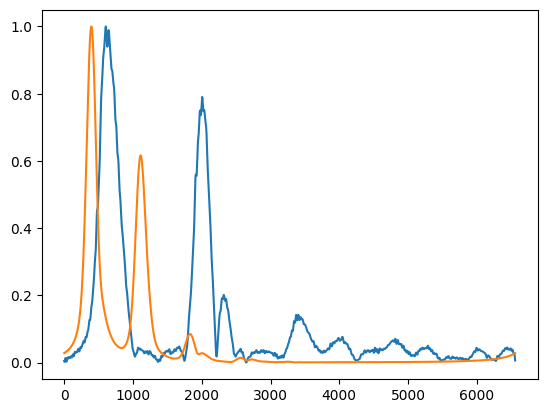

In [12]:
plt.plot(ExpTest_Data_Pro[0])
plt.plot(SimTrain_Data_Pro[0])

### Build data loader

In [13]:
# Train loader
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro, dtype=torch.float32)
Train_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor,SimTrain_Label_Pro_Tensor)
Train_Loader = DataLoader(Train_Dataset, batch_size, shuffle=True)

## Build regression model

In [14]:
class LSTMRegression(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=3, dropout=0.1, bidirectional=False):
        super(LSTMRegression, self).__init__()

        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,      # 1 channel
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        # Input x: [B, 1, L]
        x = x.permute(0, 2, 1)   # -> [B, L, 1]

        lstm_out, (h_n, c_n) = self.lstm(x)

        if self.bidirectional:
            # last layer forward + backward hidden states
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)   # [B, 2*hidden_size]
        else:
            h_last = h_n[-1]                                # [B, hidden_size]

        x = self.classifier(h_last)                         # [B, 3]
        return x

In [15]:
model = LSTMRegression(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    output_size=3,
    dropout=0.1,
    bidirectional=False
).to(device)

summary(model, input_size=(1, 1, num_samples), device=str(device))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMRegression                           [1, 3]                    --
├─LSTM: 1-1                              [1, 6560, 128]            199,168
├─Sequential: 1-2                        [1, 3]                    --
│    └─Linear: 2-1                       [1, 128]                  16,512
│    └─LeakyReLU: 2-2                    [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 3]                    387
Total params: 216,067
Trainable params: 216,067
Non-trainable params: 0
Total mult-adds (G): 1.31
Input size (MB): 0.03
Forward/backward pass size (MB): 6.72
Params size (MB): 0.86
Estimated Total Size (MB): 7.61

## Compile and train regression model

In [15]:
# Instantiate and train
model = LSTMRegression(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    output_size=3,
    dropout=0.1,
    bidirectional=False
).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [16]:
def _save_checkpoint(epoch):
    ckp = model.state_dict()
    path = f'./Saved_Model/LSTM_Model_{model_num}/checkpoint_{epoch+1}.pt'
    torch.save(ckp, path)
    with open(f'./Saved_Model/LSTM_Model_{model_num}/trainHistoryDict_{epoch+1}', 'wb') as file_pi:
        pickle.dump(loss_hist, file_pi)
    print(f'Epoch {epoch+1} | Training checkpoint saved at {path}')

In [17]:
# Training loop
start_time = time.time()
loss_hist = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in Train_Loader:
        batch_x = torch.unsqueeze(batch_x,1).to(device)
        batch_y = batch_y.to(device)
        output = model(batch_x)
        loss = criterion(output, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(Train_Loader):.6f}")
    loss_hist.append(epoch_loss)
            
    if save_every is not None and (epoch+1) % save_every == 0:
        _save_checkpoint(epoch)

end_time = time.time()
print(f"Training time: {(end_time - start_time) / 60:.1f} min")

Epoch 1/100, Loss: 0.161443
Epoch 2/100, Loss: 0.114350
Epoch 3/100, Loss: 0.114308
Epoch 4/100, Loss: 0.114249
Epoch 5/100, Loss: 0.114199
Epoch 6/100, Loss: 0.114115
Epoch 7/100, Loss: 0.113783
Epoch 8/100, Loss: 0.113764
Epoch 9/100, Loss: 0.113688
Epoch 10/100, Loss: 0.113655
Epoch 10 | Training checkpoint saved at ./Saved_Model/LSTM_Model_2/checkpoint_10.pt
Epoch 11/100, Loss: 0.113747
Epoch 12/100, Loss: 0.113719
Epoch 13/100, Loss: 0.113474
Epoch 14/100, Loss: 0.113552
Epoch 15/100, Loss: 0.113573
Epoch 16/100, Loss: 0.113579
Epoch 17/100, Loss: 0.113490
Epoch 18/100, Loss: 0.113460
Epoch 19/100, Loss: 0.113225
Epoch 20/100, Loss: 0.113454
Epoch 20 | Training checkpoint saved at ./Saved_Model/LSTM_Model_2/checkpoint_20.pt
Epoch 21/100, Loss: 0.113398
Epoch 22/100, Loss: 0.113397
Epoch 23/100, Loss: 0.113427
Epoch 24/100, Loss: 0.113295
Epoch 25/100, Loss: 0.113370
Epoch 26/100, Loss: 0.113239
Epoch 27/100, Loss: 0.113252
Epoch 28/100, Loss: 0.112711
Epoch 29/100, Loss: 0.112800


## Test loss curve

In [16]:
Test_R_all = np.zeros((int(num_epochs/save_every),1))

for j in range(int(num_epochs/save_every)):
    
    # Load trained autoencoder
    model.load_state_dict(torch.load(f'./Saved_Model/LSTM_Model_{model_num}/checkpoint_{(j+1)*10}.pt'))
    
    # Evaluate using the validation dataset
    model.eval()
    with torch.no_grad():
        ExpTest_Pred_Pro = model(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1).to(device))
    ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()

    # De-normalize the predictions
    ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

    for i in range(ExpTest_Pred_Pro.shape[1]):
        ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
            (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])
    
    # Calculate R
    Test_R_all[j] = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]

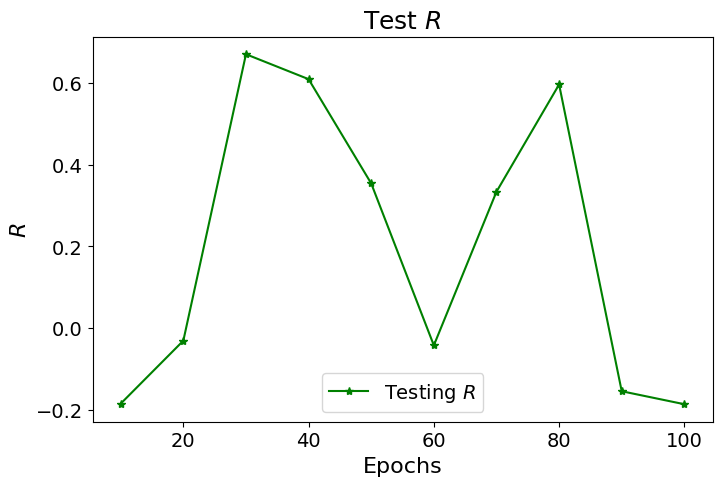

The highest test R is achieved at Epoch: 30


In [17]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(10,num_epochs+1,10), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$',fontsize=18)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('$R$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * 10)
print(f'The highest test R is achieved at Epoch: {epoch}')

## Load trained regression model

In [18]:
select_epochs = 20

In [19]:
# Load trained autoencoder
model.load_state_dict(torch.load(f'./Saved_Model/LSTM_Model_{model_num}/checkpoint_{select_epochs}.pt'))

# Load train history
with open(f'./Saved_Model/LSTM_Model_{model_num}/trainHistoryDict_{select_epochs}', 'rb') as file_pi:
        loss_hist = pickle.load(file_pi)

## Evaluate using experimental tesing dataset

In [20]:
# Evaluate using the experimental testing dataset
model.eval()
with torch.no_grad():
    ExpTest_Pred_Pro = model(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1).to(device))
ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()
    
# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(ExpTest_Pred_Pro.shape[1]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred[:,0] - ExpTest_Label[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_Label[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 MSE on experimental tesing dataset: 10.5038709738
p1 R2 on experimental tesing dataset: -0.0015079457
p1 R on experimental tesing dataset: -0.0062554416
p1 Bias on experimental tesing dataset: -0.1245986811


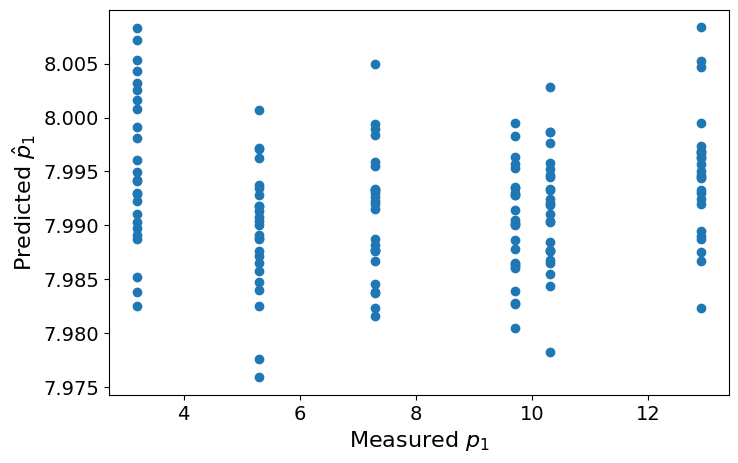

In [21]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,0],ExpTest_Pred[:,0])
plt.xlabel('Measured $p_1$',fontsize=16)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [22]:
# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred[:,1] - ExpTest_Label[:,1]) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label[:,1], ExpTest_Pred[:,1])
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred[:,1]) - np.mean(ExpTest_Label[:,1])
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 MSE on experimental tesing dataset: 0.0003440743
c1 R2 on experimental tesing dataset: -0.0011723876
c1 R on experimental tesing dataset: -0.0308493098
c1 Bias on experimental tesing dataset: -0.0006102464


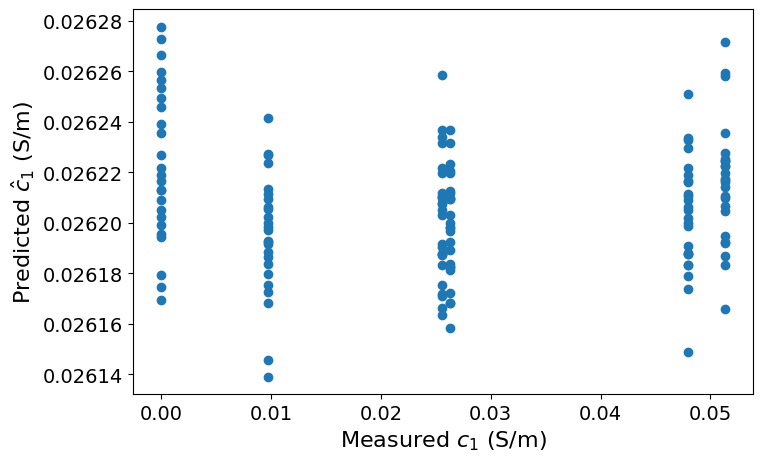

In [23]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,1],ExpTest_Pred[:,1])
plt.xlabel('Measured $c_1$ (S/m)',fontsize=16)
plt.ylabel('Predicted $\hat{c}_1$ (S/m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [24]:
# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred[:,2] - ExpTest_Label[:,2]) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label[:,2], ExpTest_Pred[:,2])
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label[:,2].astype(float), ExpTest_Pred[:,2].astype(float))[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred[:,2]) - np.mean(ExpTest_Label[:,2])
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

d1 MSE on experimental tesing dataset: 0.0000021406
d1 R2 on experimental tesing dataset: -694648190617036286674862080.0000000000
d1 R on experimental tesing dataset: -0.0000000000
d1 Bias on experimental tesing dataset: -0.0014624062


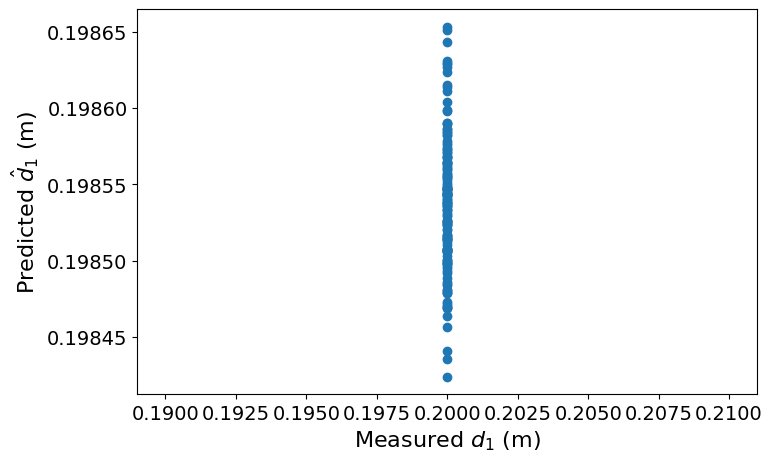

In [25]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,2],ExpTest_Pred[:,2])
plt.xlabel('Measured $d_1$ (m)',fontsize=16)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [26]:
specimen_1_pred_mean_p1 = np.mean(ExpTest_Pred[0:25,0])
specimen_2_pred_mean_p1 = np.mean(ExpTest_Pred[25:50,0])
specimen_3_pred_mean_p1 = np.mean(ExpTest_Pred[50:75,0])
specimen_4_pred_mean_p1 = np.mean(ExpTest_Pred[75:100,0])
specimen_5_pred_mean_p1 = np.mean(ExpTest_Pred[100:125,0])
specimen_6_pred_mean_p1 = np.mean(ExpTest_Pred[125:150,0])
ExpTest_Pred_Pro_p1 = np.array([specimen_1_pred_mean_p1,specimen_2_pred_mean_p1,specimen_3_pred_mean_p1,
                                    specimen_4_pred_mean_p1,specimen_5_pred_mean_p1,specimen_6_pred_mean_p1])
ExpTest_Label_Pro_p1 = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],
                                    ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

In [27]:
# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred_Pro_p1 - ExpTest_Label_Pro_p1) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred_Pro_p1) - np.mean(ExpTest_Label_Pro_p1)
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 R2 on experimental tesing dataset: -0.0015047469
p1 MSE on experimental tesing dataset: 10.5038374250
p1 R on experimental tesing dataset: -0.0172022742
p1 Bias on experimental tesing dataset: -0.1245986811


p1 R on experimental tesing dataset: -0.0172022742
p1 Bias on experimental tesing dataset: -0.1245986811
p1 MSE on experimental tesing dataset: 10.5038374250
p1 RMSE on experimental tesing dataset: 3.2409624226
p1 ubMSE on experimental tesing dataset: 3.2385664411


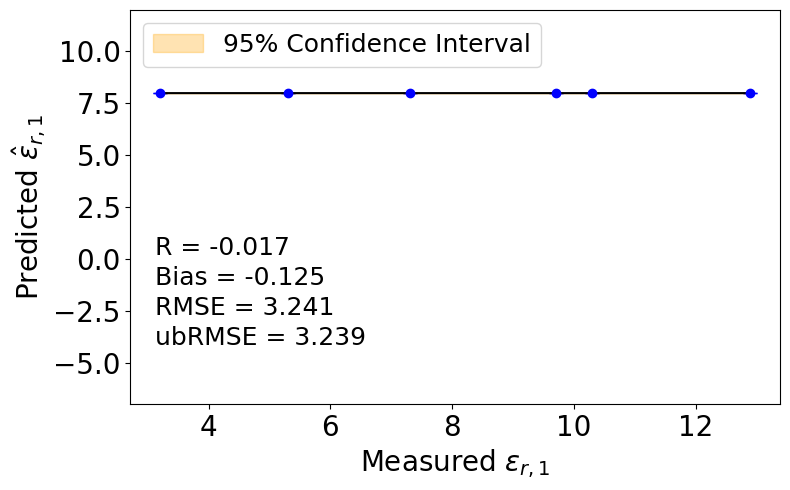

In [28]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,0])
mean_2 = np.mean(ExpTest_Pred[25:50,0])
mean_3 = np.mean(ExpTest_Pred[50:75,0])
mean_4 = np.mean(ExpTest_Pred[75:100,0])
mean_5 = np.mean(ExpTest_Pred[100:125,0])
mean_6 = np.mean(ExpTest_Pred[125:150,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,0])
std_2 = np.std(ExpTest_Pred[25:50,0])
std_3 = np.std(ExpTest_Pred[50:75,0])
std_4 = np.std(ExpTest_Pred[75:100,0])
std_5 = np.std(ExpTest_Pred[100:125,0])
std_6 = np.std(ExpTest_Pred[125:150,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='orange', alpha=0.3, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='blue', alpha=0.2, label='95% Prediction Interval')

plt.xlabel(r'Measured $\varepsilon_{r,1}$',fontsize=20)
plt.ylabel(r'Predicted $\hat{\varepsilon}_{r,1}$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.2, 0.48, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.2, 0.42, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.2, 0.36, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.2, 0.30, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-7,12])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Permittivity_LSTM_AllSamples', dpi=600)

In [29]:
specimen_1_pred_mean_c1 = np.mean(ExpTest_Pred[0:25,1])
specimen_2_pred_mean_c1 = np.mean(ExpTest_Pred[25:50,1])
specimen_3_pred_mean_c1 = np.mean(ExpTest_Pred[50:75,1])
specimen_4_pred_mean_c1 = np.mean(ExpTest_Pred[75:100,1])
specimen_5_pred_mean_c1 = np.mean(ExpTest_Pred[100:125,1])
specimen_6_pred_mean_c1 = np.mean(ExpTest_Pred[125:150,1])
ExpTest_Pred_Pro_c1 = np.array([specimen_1_pred_mean_c1,specimen_2_pred_mean_c1,specimen_3_pred_mean_c1,
                                    specimen_4_pred_mean_c1,specimen_5_pred_mean_c1,specimen_6_pred_mean_c1])
ExpTest_Label_Pro_c1 = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],
                                    ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

In [30]:
# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred_Pro_c1 - ExpTest_Label_Pro_c1) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred_Pro_c1) - np.mean(ExpTest_Label_Pro_c1)
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 R2 on experimental tesing dataset: -0.0011707075
c1 MSE on experimental tesing dataset: 0.0003440737
c1 R on experimental tesing dataset: -0.0792931883
c1 Bias on experimental tesing dataset: -0.0006102464


c1 R on experimental tesing dataset: -0.0792931883
c1 Bias on experimental tesing dataset: -0.0006102464
c1 MSE on experimental tesing dataset: 0.0003440737
c1 RMSE on experimental tesing dataset: 0.0185492244
c1 ubMSE on experimental tesing dataset: 0.0185391836


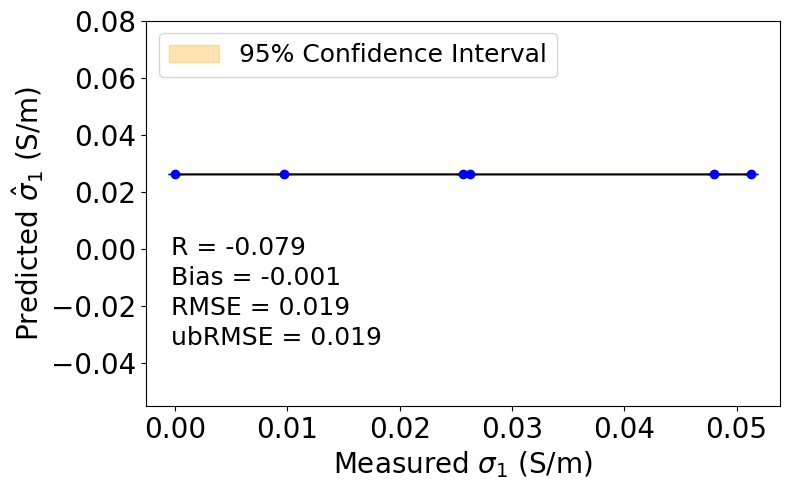

In [31]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,1])
mean_2 = np.mean(ExpTest_Pred[25:50,1])
mean_3 = np.mean(ExpTest_Pred[50:75,1])
mean_4 = np.mean(ExpTest_Pred[75:100,1])
mean_5 = np.mean(ExpTest_Pred[100:125,1])
mean_6 = np.mean(ExpTest_Pred[125:150,1])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,1])
std_2 = np.std(ExpTest_Pred[25:50,1])
std_3 = np.std(ExpTest_Pred[50:75,1])
std_4 = np.std(ExpTest_Pred[75:100,1])
std_5 = np.std(ExpTest_Pred[100:125,1])
std_6 = np.std(ExpTest_Pred[125:150,1])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('c1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('c1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('c1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='orange', alpha=0.3, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='blue', alpha=0.2, label='95% Prediction Interval')

plt.xlabel(r'Measured $\sigma_1$ (S/m)',fontsize=20)
plt.ylabel(r'Predicted $\hat{\sigma}_1$ (S/m)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.22, 0.48, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.22, 0.42, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.22, 0.36, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.22, 0.30, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-0.055,0.08])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Conductivity_LSTM_AllSamples', dpi=600)

In [32]:
specimen_1_pred_mean_d1 = np.mean(ExpTest_Pred[0:25,2])
specimen_2_pred_mean_d1 = np.mean(ExpTest_Pred[25:50,2])
specimen_3_pred_mean_d1 = np.mean(ExpTest_Pred[50:75,2])
specimen_4_pred_mean_d1 = np.mean(ExpTest_Pred[75:100,2])
specimen_5_pred_mean_d1 = np.mean(ExpTest_Pred[100:125,2])
specimen_6_pred_mean_d1 = np.mean(ExpTest_Pred[125:150,2])
ExpTest_Pred_Pro_d1 = np.array([specimen_1_pred_mean_d1,specimen_2_pred_mean_d1,specimen_3_pred_mean_d1,
                                    specimen_4_pred_mean_d1,specimen_5_pred_mean_d1,specimen_6_pred_mean_d1])
ExpTest_Label_Pro_d1 = np.array([ExpTest_Label[0,2],ExpTest_Label[25,2],ExpTest_Label[50,2],
                                    ExpTest_Label[75,2],ExpTest_Label[100,2],ExpTest_Label[125,2]])

In [33]:
# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred_Pro_d1 - ExpTest_Label_Pro_d1) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred_Pro_d1) - np.mean(ExpTest_Label_Pro_d1)
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

# RMSE
ExpTest_RMSE_d1 = np.sqrt(ExpTest_MSE_d1)
print('d1 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_d1))

# ubRMSE
ExpTest_ubRMSE_d1 = np.sqrt((ExpTest_RMSE_d1 ** 2 - ExpTest_Bias_d1 ** 2))
print('d1 ubRMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_d1))

d1 R2 on experimental tesing dataset: -2776424360277124595920666624.0000000000
d1 MSE on experimental tesing dataset: 0.0000021389
d1 R on experimental tesing dataset: -0.0000000000
d1 Bias on experimental tesing dataset: -0.0014624062
d1 RMSE on experimental tesing dataset: 0.0014624909
d1 ubRMSE on experimental tesing dataset: 0.0000157346


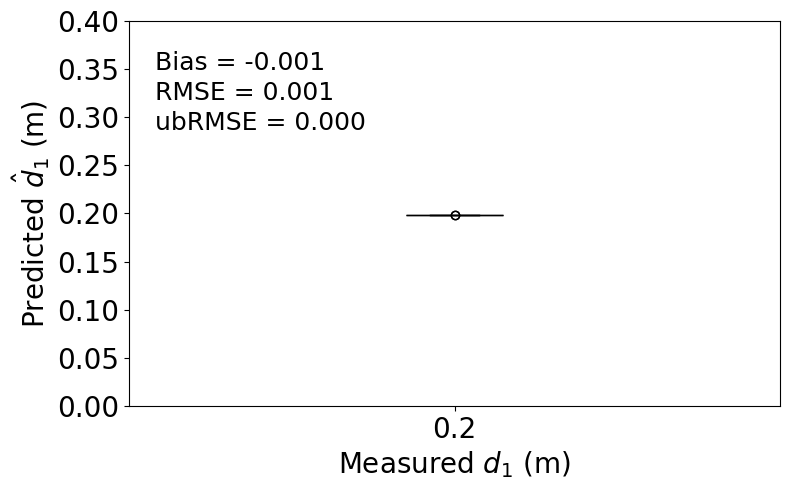

In [34]:
# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot(ExpTest_Pred[:,2],patch_artist=True,meanline=True,showmeans=True)
colors = ['orange']
# fill with colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $d_1$ (m)',fontsize=20)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=20)
labels = ['0.2']
plt.xticks([1], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.ylim([0,0.4])
plt.figtext(0.2, 0.85, f'Bias = %.3f' % ExpTest_Bias_d1, fontsize=18)
plt.figtext(0.2, 0.79, f'RMSE = %.3f' % ExpTest_RMSE_d1, fontsize=18)
plt.figtext(0.2, 0.73, f'ubRMSE = %.3f' % ExpTest_ubRMSE_d1, fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Depth_LSTM_AllSamples', dpi=600)

In [35]:
np.std(ExpTest_Pred[:,2])

4.379560709815882e-05